## Practice: Basic Artificial Neural Networks
Credits: this notebook belongs to [Practical DL](https://docs.google.com/forms/d/e/1FAIpQLScvrVtuwrHSlxWqHnLt1V-_7h2eON_mlRR6MUb3xEe5x9LuoA/viewform?usp=sf_link) course by Yandex School of Data Analysis.

We will start working with neural networks on the practice session. Your homework will be to finish the implementation of the layers.

In [ ]:
%matplotlib inline
from time import time, sleep
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
%run modules.ipynb

# Toy example

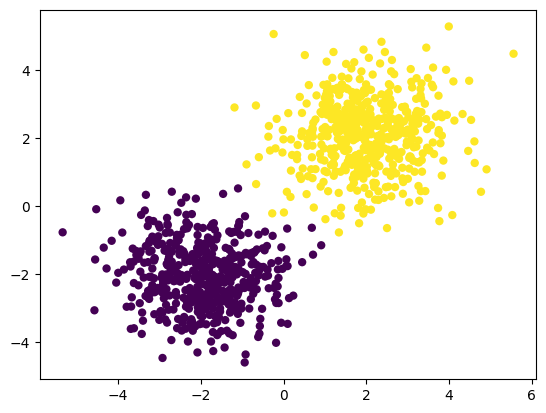

In [2]:
# Generate some data
N = 500

X1 = np.random.randn(N,2) + np.array([2,2])
X2 = np.random.randn(N,2) + np.array([-2,-2])

Y = np.concatenate([np.ones(N),np.zeros(N)])[:,None]
Y = np.hstack([Y, 1-Y])

X = np.vstack([X1,X2])
plt.scatter(X[:,0],X[:,1], c = Y[:,0], edgecolors= 'none')

In [3]:
net = Sequential()
net.add(Linear(2, 2))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

print(net)

Linear 2 -> 2
LogSoftMax



In [4]:
# Iptimizer params
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

# Looping params
n_epoch = 20
batch_size = 128

In [5]:
# batch generator
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]
        
    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        
        batch_idx = indices[start:end]
    
        yield X[batch_idx], Y[batch_idx]

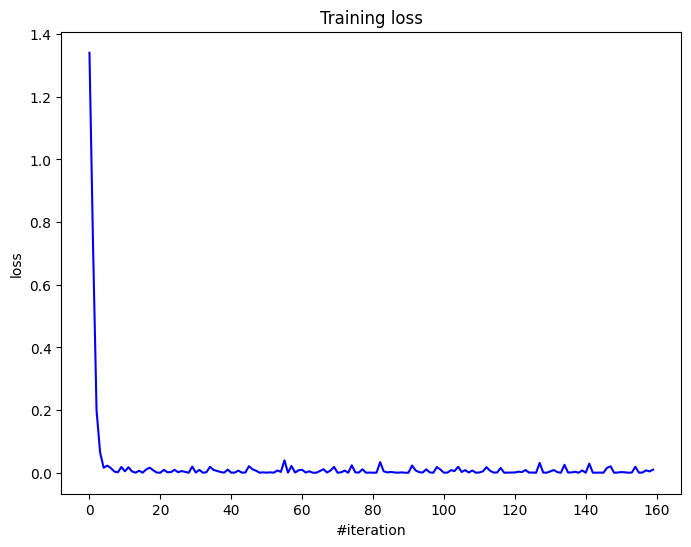

Current loss: 0.009869


In [6]:
loss_history = []

for i in range(n_epoch):
    for x_batch, y_batch in get_batches((X, Y), batch_size):
        
        net.zeroGradParameters()
        
        # Forward
        predictions = net.forward(x_batch)
        loss = criterion.forward(predictions, y_batch)
    
        # Backward
        dp = criterion.backward(predictions, y_batch)
        net.backward(x_batch, dp)
        
        # Update weights
        sgd_momentum(net.getParameters(), 
                     net.getGradParameters(), 
                     optimizer_config,
                     optimizer_state)      
        
        loss_history.append(loss)

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 6))
        
    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.show()
    
    print('Current loss: %f' % loss)

# Digit classification

In [ ]:
!wget https://raw.githubusercontent.com/girafe-ai/ml-course/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py -nc

In [ ]:
import mnist
X_train, y_train, X_val, y_val, X_test, y_test = mnist.load_dataset()

In [12]:
# One-hot encode the labels
def one_hot(y, num_classes):
    y_onehot = np.zeros((len(y), num_classes))
    y_onehot[np.arange(len(y)), y] = 1
    return y_onehot

# One-hot encode MNIST labels
Y_train = one_hot(y_train, 10)
Y_val = one_hot(y_val, 10)
Y_test = one_hot(y_test, 10)

# Flatten MNIST images
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

### Compare activation functions

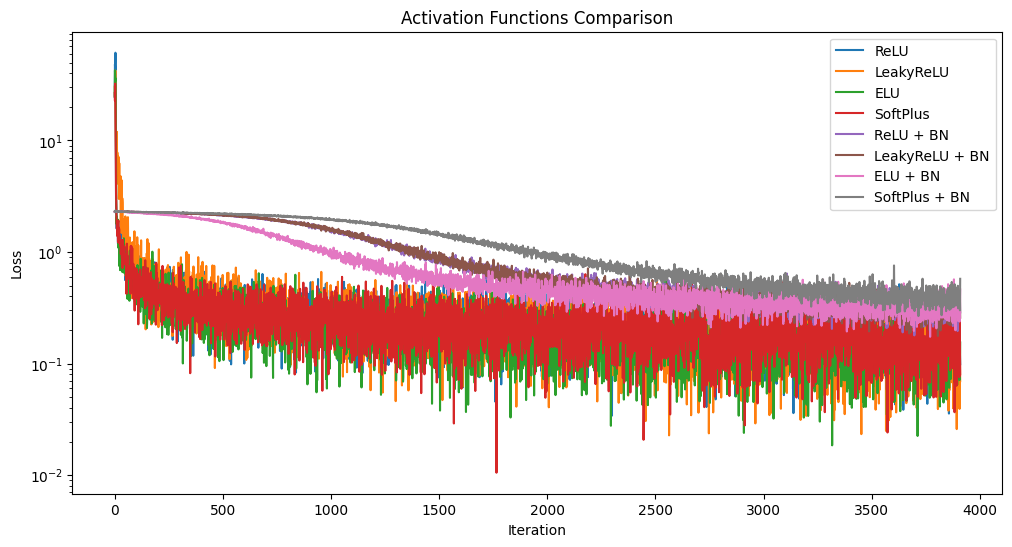

In [13]:
def train_with_activation(activation_fn, use_bn=False):
    net = Sequential()
    net.add(Linear(784, 100))
    if use_bn:
        net.add(BatchNormalization())
        net.add(ChannelwiseScaling(100))
    net.add(activation_fn())
    net.add(Linear(100, 10))
    net.add(LogSoftMax())
    
    criterion = ClassNLLCriterion()
    optimizer_config = {'learning_rate': 1e-3, 'momentum': 0.9}
    optimizer_state = {}
    
    loss_history = []
    for epoch in range(10):
        for x_batch, y_batch in get_batches((X_train, Y_train), 128):
            net.zeroGradParameters()
            predictions = net.forward(x_batch)
            loss = criterion.forward(predictions, y_batch)
            dp = criterion.backward(predictions, y_batch)
            net.backward(x_batch, dp)
            sgd_momentum(net.getParameters(), net.getGradParameters(), optimizer_config, optimizer_state)
            loss_history.append(loss)
    return loss_history

# Compare activations
activations = [ReLU, LeakyReLU, ELU, SoftPlus]
losses = {}
for act in activations:
    losses[str(act())] = train_with_activation(act)

# Compare with BatchNorm
losses_bn = {}
for act in activations:
    losses_bn[str(act()) + " + BN"] = train_with_activation(act, use_bn=True)

# Plot results
plt.figure(figsize=(12, 6))
for name, history in {**losses, **losses_bn}.items():
    plt.plot(history, label=name)
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Activation Functions Comparison')
plt.yscale('log')
plt.show()

### Compare optimizers

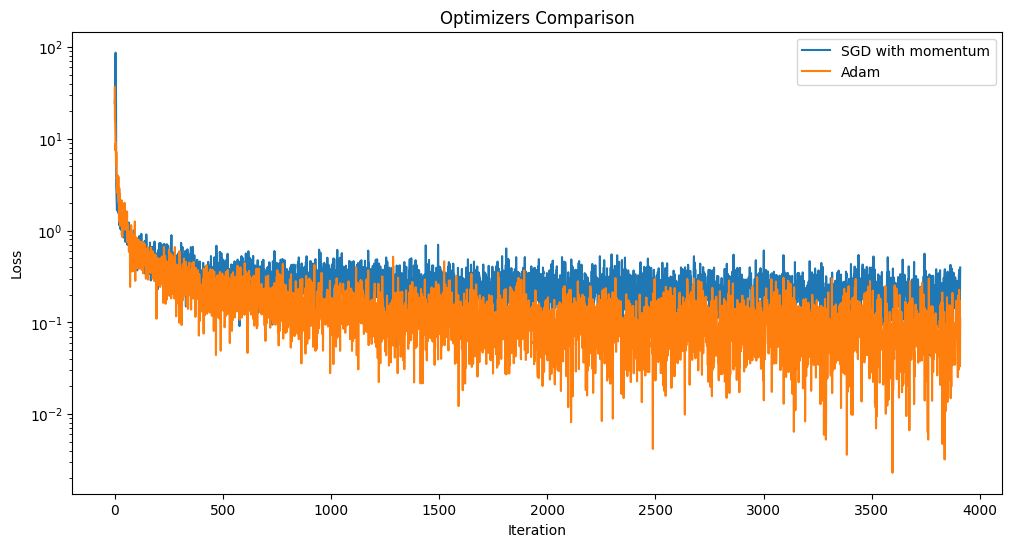

In [14]:
def train_with_optimizer(optimizer_fn):
    net = Sequential()
    net.add(Linear(784, 100))
    net.add(ReLU())
    net.add(Linear(100, 10))
    net.add(LogSoftMax())
    
    criterion = ClassNLLCriterion()
    
    if optimizer_fn == sgd_momentum:
        config = {'learning_rate': 1e-3, 'momentum': 0.9}
    else:
        config = {'learning_rate': 1e-3, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8}
    
    state = {}
    loss_history = []
    for epoch in range(10):
        for x_batch, y_batch in get_batches((X_train, Y_train), 128):
            net.zeroGradParameters()
            predictions = net.forward(x_batch)
            loss = criterion.forward(predictions, y_batch)
            dp = criterion.backward(predictions, y_batch)
            net.backward(x_batch, dp)
            optimizer_fn(net.getParameters(), net.getGradParameters(), config, state)
            loss_history.append(loss)
    return loss_history

sgd_loss = train_with_optimizer(sgd_momentum)
adam_loss = train_with_optimizer(adam_optimizer)

plt.figure(figsize=(12, 6))
plt.plot(sgd_loss, label='SGD with momentum')
plt.plot(adam_loss, label='Adam')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Optimizers Comparison')
plt.yscale('log')
plt.show()

### Final model with dropout and learning rate decay

Test accuracy: 0.9795


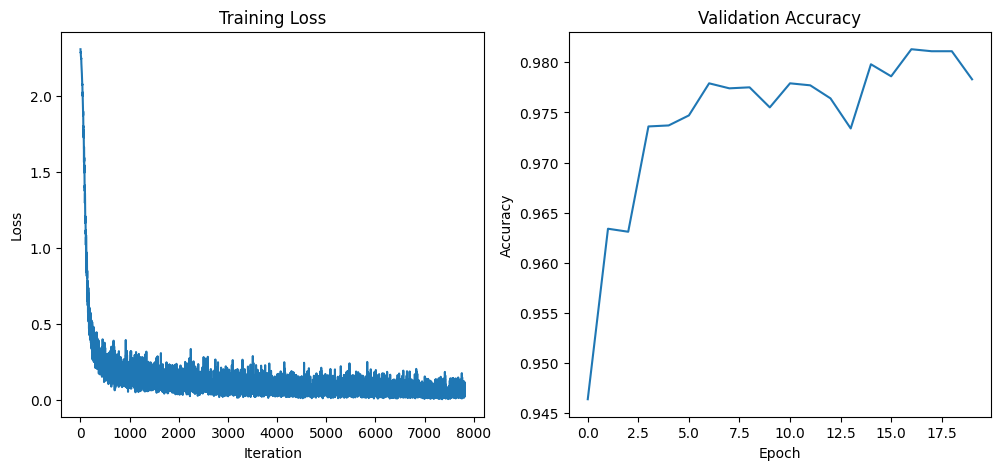

In [15]:
def train_final_model():
    net = Sequential()
    net.add(Linear(784, 256))
    net.add(BatchNormalization())
    net.add(ChannelwiseScaling(256))
    net.add(ReLU())
    net.add(Dropout(0.5))
    net.add(Linear(256, 128))
    net.add(BatchNormalization())
    net.add(ChannelwiseScaling(128))
    net.add(ReLU())
    net.add(Dropout(0.3))
    net.add(Linear(128, 10))
    net.add(LogSoftMax())
    
    criterion = ClassNLLCriterion()
    optimizer_config = {'learning_rate': 1e-3, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8}
    optimizer_state = {}
    
    loss_history = []
    val_accuracy = []
    
    for epoch in range(20):
        # Learning rate decay
        optimizer_config['learning_rate'] *= 0.95
        
        net.train()
        for x_batch, y_batch in get_batches((X_train, Y_train), 128):
            net.zeroGradParameters()
            predictions = net.forward(x_batch)
            loss = criterion.forward(predictions, y_batch)
            dp = criterion.backward(predictions, y_batch)
            net.backward(x_batch, dp)
            adam_optimizer(net.getParameters(), net.getGradParameters(), optimizer_config, optimizer_state)
            loss_history.append(loss)
        
        # Validation
        net.evaluate()
        val_pred = net.forward(X_val)
        val_acc = (val_pred.argmax(axis=1) == y_val).mean()
        val_accuracy.append(val_acc)
    
    return net, loss_history, val_accuracy

final_net, final_loss, val_acc = train_final_model()

# Test accuracy
final_net.evaluate()
test_pred = final_net.forward(X_test)
test_accuracy = (test_pred.argmax(axis=1) == y_test).mean()
print(f"Test accuracy: {test_accuracy:.4f}")

# Plot training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(final_loss)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.subplot(1, 2, 2)
plt.plot(val_acc)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.show()

### PyTorch implementation for comparison

PyTorch test accuracy: 0.9816


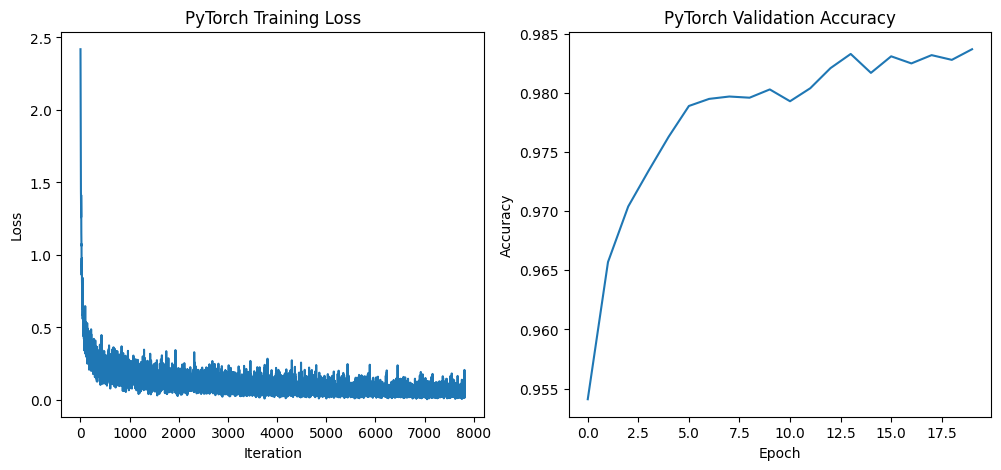

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
Y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
Y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
Y_test_tensor = torch.LongTensor(y_test)

# Create datasets and loaders
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

# Define the same architecture in PyTorch
class TorchModel(nn.Module):
    def __init__(self):
        super(TorchModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim=1)
        )
    
    def forward(self, x):
        return self.net(x)

# Training function
def train_pytorch_model():
    model = TorchModel()
    criterion = nn.NLLLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
    
    loss_history = []
    val_accuracy = []
    
    for epoch in range(20):
        model.train()
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            loss_history.append(loss.item())
        
        scheduler.step()
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                predictions = model(x_batch)
                _, predicted = torch.max(predictions.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        val_accuracy.append(correct / total)
    
    return model, loss_history, val_accuracy

torch_model, torch_loss, torch_val_acc = train_pytorch_model()

# Test accuracy
torch_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        predictions = torch_model(x_batch)
        _, predicted = torch.max(predictions.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

print(f"PyTorch test accuracy: {correct / total:.4f}")

# Plot training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(torch_loss)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('PyTorch Training Loss')

plt.subplot(1, 2, 2)
plt.plot(torch_val_acc)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('PyTorch Validation Accuracy')
plt.show()

### Results analysis

print("Activation Functions Analysis:")
print("1. ReLU is the fastest to compute and works well in most cases")
print("2. LeakyReLU and ELU can help with dying ReLU problem")
print("3. SoftPlus is smoother but computationally more expensive")
print("4. BatchNorm helps stabilize training and often improves performance")

print("\nOptimizers Comparison:")
print("1. Adam usually converges faster than SGD with momentum")
print("2. Adam requires less tuning of learning rate")
print("3. SGD with momentum can sometimes reach better final performance with proper tuning")

print("\nFinal Model Performance:")
print(f"Our implementation: {test_accuracy:.2%} accuracy")
print(f"PyTorch implementation: {correct / total:.2%} accuracy")
print("The small difference comes from implementation details and random initialization")